In [1]:
"""This is an example of demand forecasting with a TFT model using the Stallion data from kaggle."""

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor
from lightning.pytorch.loggers import TensorBoardLogger
import numpy as np
import pandas as pd
import torch

from pytorch_forecasting import Baseline, TemporalFusionTransformer, TimeSeriesDataSet
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import MAE, SMAPE, QuantileLoss
from pytorch_forecasting.models.temporal_fusion_transformer.tuning import (
    optimize_hyperparameters,
)

#### Load data and engineer features


In [2]:
from pytorch_forecasting.data.examples import get_stallion_data

data: pd.DataFrame = get_stallion_data()
print(data.head())
print(data.info())

        agency     sku    volume       date  industry_volume  soda_volume  \
0    Agency_22  SKU_01   52.2720 2013-01-01        492612703    718394219   
238  Agency_37  SKU_04    0.0000 2013-01-01        492612703    718394219   
237  Agency_59  SKU_03  812.9214 2013-01-01        492612703    718394219   
236  Agency_11  SKU_01  316.4400 2013-01-01        492612703    718394219   
235  Agency_05  SKU_05  420.9093 2013-01-01        492612703    718394219   

     avg_max_temp  price_regular  price_actual    discount  ...  labor_day  \
0       25.845238    1168.903668   1069.166193   99.737475  ...          0   
238     26.505000    1852.273642   1611.466298  240.807344  ...          0   
237     22.219737    1270.795012   1197.184260   73.610752  ...          0   
236     25.360000    1176.155397   1082.757488   93.397909  ...          0   
235     24.079012    1327.003396   1207.822992  119.180404  ...          0   

     independence_day  revolution_day_memorial  regional_games  \
0 

In [ ]:
# Feature engineering
# add time index
data["time_idx"] = data["date"].dt.year * 12 + data["date"].dt.month  # make sure there is no gap in time.
data["time_idx"] -= data["time_idx"].min()

# add additional features
data["month"] = data["date"].dt.month.astype(str).astype("category") 
data["log_volume"] = np.log(data["volume"] + 1e-8)

data["avg_volume_by_sku"] = data.groupby(["time_idx", "sku"], observed=True)["volume"].transform("mean")
# data["avg_volume_by_agency"] = data.groupby(["time_idx", "agency"], observed=True)["volume"].transform("mean")

# add moving average volumes
data["moving_avg_volume_by_agency_sku_6"] = data.sort_values("date").groupby(
    ["agency", "sku"], observed=True)["volume"].transform(
    lambda x: x.rolling(window=6).mean()
)
data["moving_avg_volume_by_agency_sku_3"] = data.sort_values("date").groupby(
    ["agency", "sku"], observed=True)["volume"].transform(
    lambda x: x.rolling(window=3).mean()
)
# fill NaN values with 0
data["moving_avg_volume_by_agency_sku_6"] = data["moving_avg_volume_by_agency_sku_6"].fillna(0)
data["moving_avg_volume_by_agency_sku_3"] = data["moving_avg_volume_by_agency_sku_3"].fillna(0)

# encode special days as a single variable and thus need to first reverse one-hot encoding
special_days: list[str] = [
    "easter_day",
    "good_friday",
    "new_year",
    "christmas",
    "labor_day",
    "independence_day",
    "revolution_day_memorial",
    "regional_games",
    "fifa_u_17_world_cup",
    "football_gold_cup",
    "beer_capital",
    "music_fest",
]
data[special_days] = (
    data[special_days].apply(lambda x: x.map({0: "-", 1: x.name})).astype("category")
)
data.sample(10, random_state=42)

,agency,sku,volume,date,industry_volume,soda_volume,avg_max_temp,price_regular,price_actual,discount,...,beer_capital,music_fest,discount_in_percent,timeseries,time_idx,month,log_volume,avg_volume_by_sku,moving_avg_volume_by_agency_sku_6,moving_avg_volume_by_agency_sku_3
15816,Agency_23,SKU_04,58.53240,2013-07-01,508376577,869768947,30.583529,1973.631989,1803.869933,169.762056,...,-,-,8.601505,329,6,7,4.069580,1441.632155,38.382600,47.41380
1594,Agency_37,SKU_18,0.50850,2017-01-01,562154016,845614054,32.185603,1552.300885,1443.743363,108.557522,...,-,-,6.993330,6,48,1,-0.676290,1.800937,1.792550,1.46900
14414,Agency_16,SKU_04,1092.75375,2014-06-01,553838801,865152191,24.674123,2041.644065,1876.368579,165.275486,...,-,-,8.095215,56,17,6,6.996456,1094.401195,1381.975850,1271.26900
11907,Agency_18,SKU_02,102.81600,2017-04-01,589969396,940912941,35.616900,1639.750000,1216.915704,422.834296,...,-,-,25.786510,143,51,4,4.632941,2658.906000,73.854000,76.82400
20230,Agency_09,SKU_04,872.49075,2015-09-01,553979958,742568762,33.089655,2113.093419,1847.401461,265.691958,...,-,-,12.573602,49,32,9,6.771352,943.880103,1556.412375,1046.44775
10211,Agency_38,SKU_07,47.79000,2017-03-01,613143990,886129111,25.374816,1532.790113,1525.609181,7.180932,...,-,music_fest,0.468488,274,50,3,3.866816,31.385893,57.451250,37.02250
10677,Agency_39,SKU_03,202.44780,2013-04-01,532390389,838099501,27.930736,1306.430270,1227.610316,78.819954,...,-,-,6.033231,341,3,4,5.310482,1564.910937,0.000000,363.18780
5845,Agency_23,SKU_21,0.00000,2014-12-01,522571730,696401477,26.228409,0.000000,0.000000,0.000000,...,-,-,0.000000,333,23,12,-18.420681,0.000000,0.000000,0.00000
15633,Agency_19,SKU_01,42.76800,2017-06-01,636846973,928366256,34.931774,1683.386364,1385.274779,298.111585,...,-,-,17.709041,159,53,6,3.755790,3310.972587,39.672000,42.66000
19966,Agency_13,SKU_01,7451.56800,2015-09-01,553979958,742568762,24.225764,1365.352825,1243.952378,121.400447,...,-,-,8.891507,275,32,9,8.916180,3387.532385,7528.302500,7209.03600


In [ ]:
# randomly check a specific sku and agency
cond = (data["agency"] == "Agency_37") & (data['sku'] == "SKU_04")
print(data[cond])

          agency     sku     volume       date  industry_volume  soda_volume  \
238    Agency_37  SKU_04    0.00000 2013-01-01        492612703    718394219   
7295   Agency_37  SKU_04    0.00000 2013-02-01        431937346    753938444   
8870   Agency_37  SKU_04    0.00000 2013-03-01        509281531    892192092   
10815  Agency_37  SKU_04    0.00000 2013-04-01        532390389    838099501   
12417  Agency_37  SKU_04    0.00000 2013-05-01        551755254    864420003   
14081  Agency_37  SKU_04    0.00000 2013-06-01        531683569    889520921   
16034  Agency_37  SKU_04    0.00000 2013-07-01        508376577    869768947   
17798  Agency_37  SKU_04    0.00000 2013-08-01        532480057    757916529   
19587  Agency_37  SKU_04    0.00000 2013-09-01        454252482    789624076   
2058   Agency_37  SKU_04    0.00000 2013-10-01        480693900    791658684   
3727   Agency_37  SKU_04    0.00000 2013-11-01        434960682    806253783   
5541   Agency_37  SKU_04    0.00000 2013

In [4]:
data.describe()

,volume,date,industry_volume,soda_volume,avg_max_temp,price_regular,price_actual,discount,avg_population_2017,avg_yearly_household_income_2017,discount_in_percent,timeseries,time_idx,log_volume,avg_volume_by_sku,moving_avg_volume_by_agency_sku_6,moving_avg_volume_by_agency_sku_3
count,21000.000000,21000,2.100000e+04,2.100000e+04,21000.000000,21000.000000,21000.000000,21000.000000,2.100000e+04,21000.000000,21000.000000,21000.00000,21000.000000,21000.000000,21000.000000,21000.000000,21000.000000
mean,1492.403982,2015-06-16 20:48:00,5.439214e+08,8.512000e+08,28.612404,1451.536344,1267.347450,184.374146,1.045065e+06,151073.494286,10.574884,174.50000,29.500000,2.464118,1492.403982,1372.226947,1446.926028
min,0.000000,2013-01-01 00:00:00,4.130518e+08,6.964015e+08,16.731034,0.000000,-3121.690141,0.000000,1.227100e+04,90240.000000,0.000000,0.00000,0.000000,-18.420681,0.000000,0.000000,0.000000
25%,8.272388,2014-03-24 06:00:00,5.090553e+08,7.890880e+08,25.374816,1311.547158,1178.365653,54.935108,6.018900e+04,110057.000000,3.749628,87.00000,14.750000,2.112923,932.285496,3.411162,6.345788
50%,158.436000,2015-06-16 00:00:00,5.512000e+08,8.649196e+08,28.479272,1495.174592,1324.695705,138.307225,1.232242e+06,131411.000000,8.948990,174.50000,29.500000,5.065351,1402.305264,105.552150,138.528375
75%,1774.793475,2016-09-08 12:00:00,5.893715e+08,9.005551e+08,31.568405,1725.652080,1517.311427,272.298630,1.729177e+06,206553.000000,15.647058,262.00000,44.250000,7.481439,2195.362302,1526.672112,1684.943625
max,22526.610000,2017-12-01 00:00:00,6.700157e+08,1.049869e+09,45.290476,19166.625000,4925.404000,19166.625000,3.137874e+06,247220.000000,226.740147,349.00000,59.000000,10.022453,4332.363750,20177.734050,21166.045000
std,2711.496882,NaN,6.288022e+07,7.824340e+07,3.972833,683.362417,587.757323,257.469968,9.291926e+05,50409.593114,9.590813,101.03829,17.318515,8.178218,1051.790829,2603.430039,2662.539595


#### Create TimeSeriesDataSet and dataloaders


In [5]:
# Set the decoder length to 6 months (forecasting nest 6 months) and encoder length to 36 months.
from pytorch_forecasting.data.timeseries import TimeSeriesDataSet


max_prediction_length = 6
max_encoder_length = 36
training_cutoff = data["time_idx"].max() - max_prediction_length

# create training and validation set
training = TimeSeriesDataSet(
    data[data["time_idx"] <= training_cutoff],
    time_idx="time_idx",
    target="volume",
    group_ids=["agency", "sku"],  # group by agency and sku to create num_agencies * num_skus time series.
    min_encoder_length=max_encoder_length // 2, 
    max_encoder_length=max_encoder_length,
    min_prediction_length=1,
    max_prediction_length=max_prediction_length,
    static_categoricals=["agency", "sku"], #  List of static categorical variables (constant over time)
    static_reals=["avg_population_2017",   #  List of static continuous variables (constant over time).
                  "avg_yearly_household_income_2017"],
    time_varying_known_categoricals=["special_days", "month"],  # List of time-varying categorical variables known in the future.
    variable_groups={"special_days": special_days},  # group of categorical variables can be treated as one variable
    time_varying_known_reals=["time_idx",
                              "price_regular",
                              "discount_in_percent"],  # List of time-varying continuous variables known in the future.
    time_varying_unknown_categoricals=[], # List of time-varying categorical variables unknown in the future.
    time_varying_unknown_reals=[  # List of time-varying continuous variables unknown in the future.
        "volume",
        "log_volume",
        "industry_volume",
        "soda_volume",
        "avg_max_temp",
        "avg_volume_by_sku",
        "moving_avg_volume_by_agency_sku_6",
        "moving_avg_volume_by_agency_sku_3",
    ],
    target_normalizer=GroupNormalizer(  #  Normalizer for the target variable (default: None).
        groups=["agency", "sku"], 
        transformation="softplus"  # use softplus and normalize by group
    ),  
    add_relative_time_idx=True, # adds a relative time index as a feature
    add_target_scales=True,  # If True, adds center and scale of target as features.
    add_encoder_length=True, # If True, adds encoder length as a feature.
)

# create validation set (predict=True), which means to predict the last max_prediction_length 
# points in time for each time series
validation: TimeSeriesDataSet = TimeSeriesDataSet.from_dataset(
    training, data, predict=True, stop_randomization=True
)

# create dataloaders for the model
batch_size = 48  
train_dataloader = training.to_dataloader(
    train=True, batch_size=batch_size
)
val_dataloader = validation.to_dataloader(
    train=False, batch_size=batch_size * 10  # set larger batch size to be efficient due to no gradient updates via backpropagation
)

#### Create baseline model


In [7]:
# calculate baseline mean absolute error, i.e. predict next value as the last available value from the history
from pytorch_forecasting.metrics import MAE, SMAPE
import warnings
warnings.filterwarnings("ignore") 

baseline_predictions = Baseline().predict(val_dataloader, return_y=True)
print("MAE: ", MAE()(baseline_predictions.output, baseline_predictions.y))
print("SMAPE: ", SMAPE()(baseline_predictions.output, baseline_predictions.y))

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


MAE:  tensor(293.0088, device='cuda:0')
SMAPE:  tensor(0.4709, device='cuda:0')


In [8]:
print(baseline_predictions.output.detach().cpu().numpy().shape)
print(baseline_predictions.y[0].cpu().numpy().shape)

(350, 6)
(350, 6)


#### Find optimal learning rate


Seed set to 17
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Number of parameters in network: 125.3k


Finding best initial lr:   0%|          | 0/100 [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_steps=100` reached.
Learning rate set to 5.623413251903491e-05
Restoring states from the checkpoint path at c:\Users\willx\DataAnalytics\Pytorch_Forecasting\Time_Series_Forecasting_with_PF\.lr_find_c52135a3-2bf8-4274-b11e-9010a5c3a49b.ckpt
Restored all states from the checkpoint at c:\Users\willx\DataAnalytics\Pytorch_Forecasting\Time_Series_Forecasting_with_PF\.lr_find_c52135a3-2bf8-4274-b11e-9010a5c3a49b.ckpt


suggested learning rate: 5.623413251903491e-05


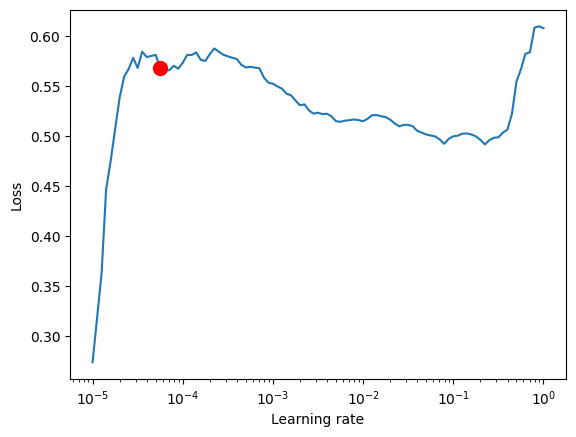

In [9]:
"""Prior to training, identify the optimal learning rate with the PyTorch Lightning learning rate finder."""

# configure network and trainer
pl.seed_everything(17)

trainer = pl.Trainer(
    accelerator="gpu",
    gradient_clip_val=0.1,
)


tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=32,  # most important hyperparameter apart from learning rate
    attention_head_size=3, # Set to up to 4 for large datasets
    dropout=0.3,  
    hidden_continuous_size=24,  # set to <= hidden_size
    loss=SMAPE(),
    optimizer="adamw",
    weight_decay=1e-2,  # AdamW weight decay
)
print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")

# find optimal learning rate
from lightning.pytorch.tuner import Tuner

res = Tuner(trainer).lr_find(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
    max_lr=1.0,
    min_lr=1e-5,
)

print(f"suggested learning rate: {res.suggestion()}")
fig = res.plot(show=True, suggest=True)
fig.show()

#### Hyperparameter tuning

Hyperparamter tuning with [optuna](https://optuna.org/) is directly build into pytorch-forecasting. For example, we can use the optimize_hyperparameters() function to optimize the TFT’s hyperparameters.


In [ ]:
import pickle

from pytorch_forecasting.models.temporal_fusion_transformer.tuning import optimize_hyperparameters

# create study
study = optimize_hyperparameters(
    train_dataloader,
    val_dataloader,
    model_path="optuna_test",
    n_trials=5,
    max_epochs=30,
    gradient_clip_val_range=(0.01, 1.0),
    hidden_size_range=(8, 128),
    hidden_continuous_size_range=(8, 128),
    attention_head_size_range=(1, 8),
    learning_rate_range=(0.001, 0.1),
    dropout_range=(0.1, 0.5),
    trainer_kwargs=dict(limit_train_batches=30),
    reduce_on_plateau_patience=4,
    use_learning_rate_finder=False,  # use Optuna to find ideal learning rate or use in-built learning rate finder
)

# save study results - also we can resume tuning at a later point in time
with open("test_study.pkl", "wb") as fout:
    pickle.dump(study, fout)

# show best hyperparameters
print(study.best_trial.params)

#### Train the model


In [10]:

# configure network and trainer
early_stop_callback = EarlyStopping(
    monitor="val_loss", min_delta=1e-4, patience=10, verbose=False, mode="min"
)
lr_logger = LearningRateMonitor()  # log the learning rate
logger = TensorBoardLogger("lightning_logs")  # logging results to a tensorboard

trainer = pl.Trainer(
    max_epochs=50,
    accelerator="gpu",
    devices=1,
    enable_model_summary=True,
    gradient_clip_val=0.1,  # clipping gradients is a hyperparameter and important to prevent divergance
    limit_train_batches=0.5,  # the number or percentage of batches used from the training set per epoch.
    # limit_val_batches=0.5,  
    enable_checkpointing=True,  # save checkpoints
    # fast_dev_run=True,  # comment in to check that networkor dataset has no serious bugs
    callbacks=[lr_logger, early_stop_callback],
    logger=logger,
)


tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=0.001,
    hidden_size=16,
    attention_head_size=3,
    dropout=0.5,
    hidden_continuous_size=12,  # updated hidden_continuous_size
    loss=SMAPE(),
    log_interval=10,  # uncomment for learning rate finder and otherwise, e.g. to 10 for logging every 10 batches
    optimizer="adamw",
    reduce_on_plateau_patience=3,
    weight_decay=0.1,
)
print(f"Number of parameters in network: {tft.size() / 1e3:.1f}k")

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


Number of parameters in network: 37.3k


In [11]:
# fit network
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | SMAPE                           | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 1.3 K  | train
3  | prescalers                         | ModuleDict                      | 408    | train
4  | static_variable_selection          | VariableSelectionNetwork        | 5.1 K  | train
5  | encoder_variable_selection         | VariableSelectionNetwork        | 13.2 K | train
6  | decoder_variable_selection         | VariableSelectionNetwork        | 4.0 K  | train
7  | static_context_variable_selection  | GatedResidualNetwork            | 1.1 K  | train
8  | static_context_initial_hidden_lstm |

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

#### Evaluate performance


In [12]:
"""PyTorch Lightning automatically checkpoints training and thus, we can easily retrieve the best model and load it."""
from pytorch_forecasting.metrics import SMAPE

# load the best model according to the validation loss
best_model_path = trainer.checkpoint_callback.best_model_path
best_tft = TemporalFusionTransformer.load_from_checkpoint(best_model_path)

# calculate mean absolute error on validation set
predictions = best_tft.predict(
    val_dataloader, mode="prediction", return_x=True, trainer_kwargs=dict(accelerator="gpu")
)
print(predictions.output.shape)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


torch.Size([350, 6])


In [ ]:
y_pred = predictions.output
y_true = predictions.x["decoder_target"]  

mae = MAE()(y_pred, y_true)
print(f"MAE: {mae:.2f}")

smape_value = SMAPE()(y_pred, y_true)
print(f"SMAPE: {smape_value * 100:.2f}%")  # both MAE and SMAPE are better than the baseline model

MAE: 268.44
SMAPE: 41.32%


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


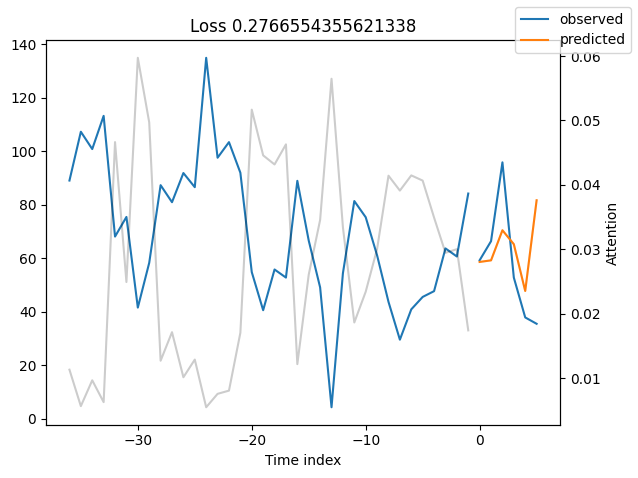

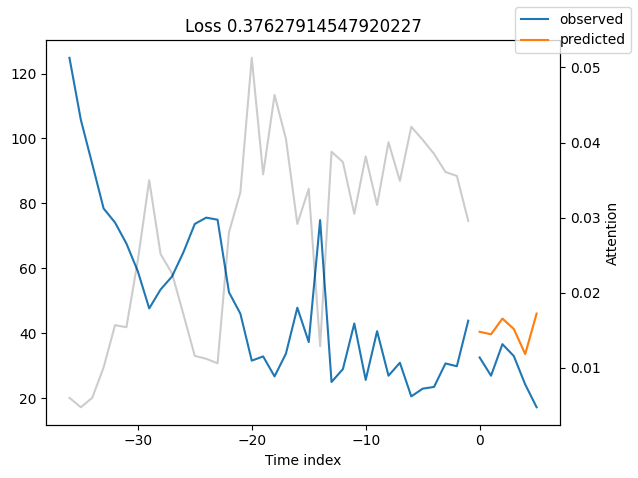

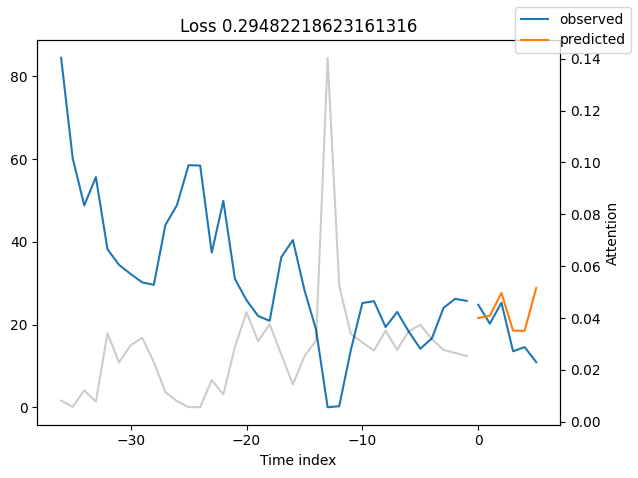

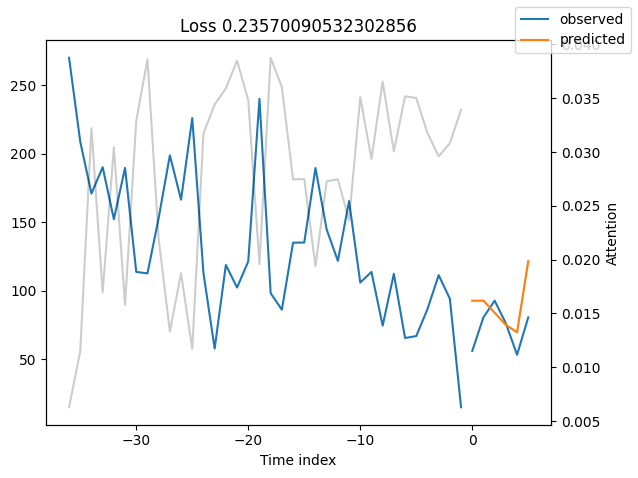

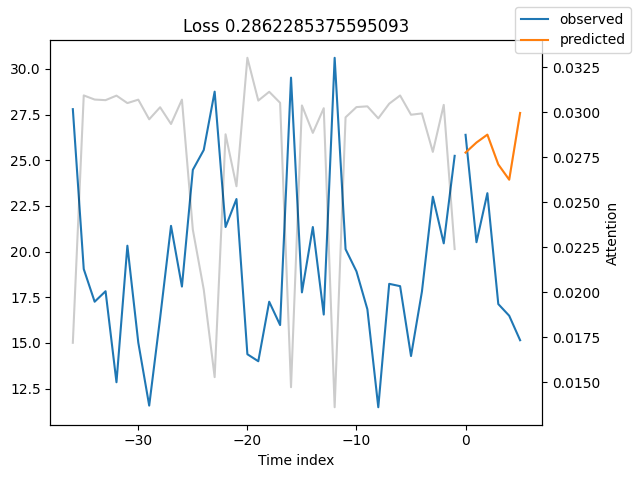

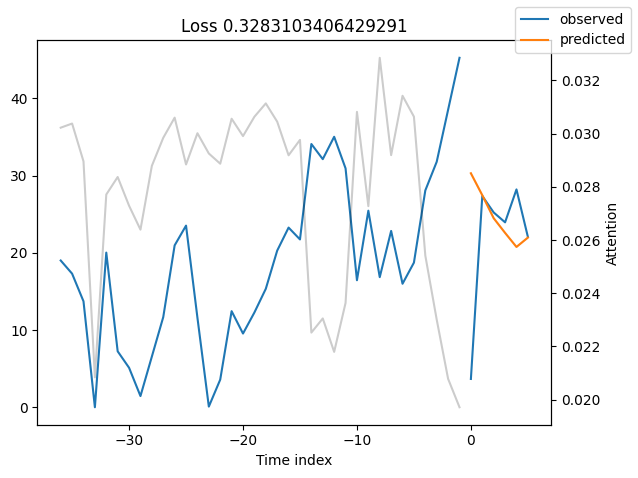

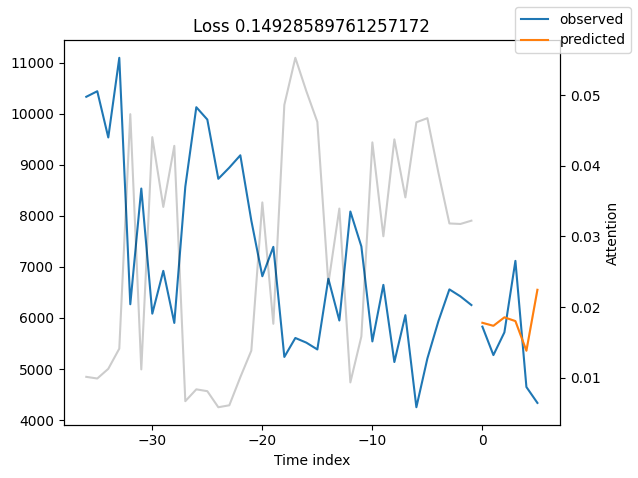

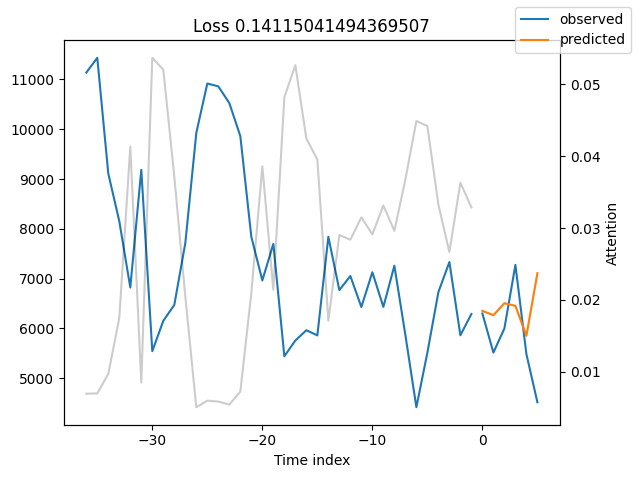

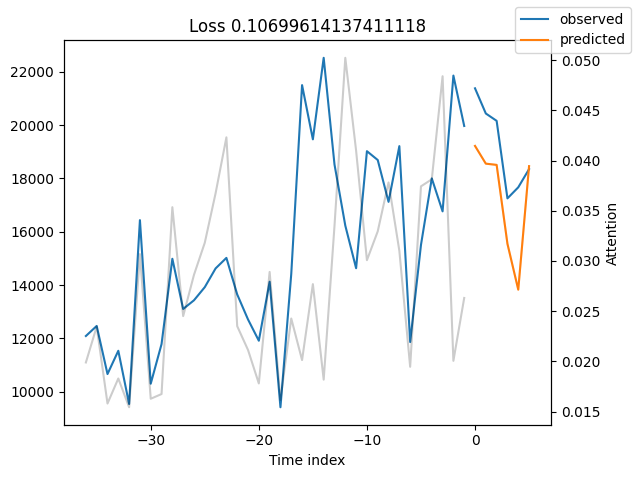

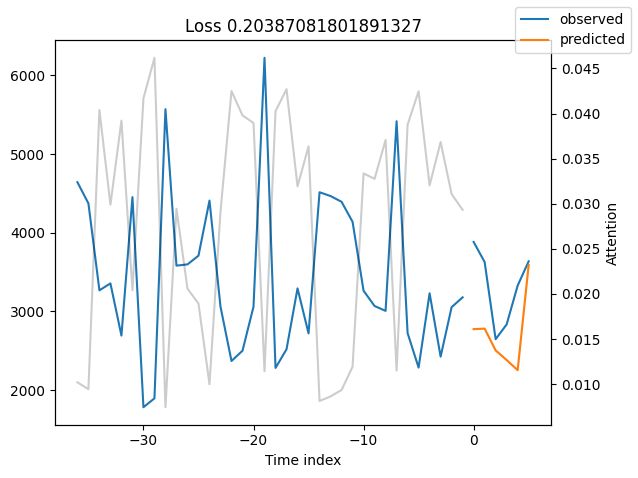

In [14]:
"""We can now also look at sample predictions directly with plot_prediction(). 
The grey lines denote the amount of attention the model pays to different points in time when making the prediction. 
This is a special feature of the Temporal Fusion Transformer."""
# raw predictions are a dictionary from which all kind of information including quantiles can be extracted
raw_predictions = best_tft.predict(
    val_dataloader, mode="raw", return_x=True, trainer_kwargs={"accelerator": "gpu", "devices": 1}
)

for idx in range(10):  # plot the first 10 examples
    best_tft.plot_prediction(
        raw_predictions.x, raw_predictions.output, idx=idx, add_loss_to_title=True
    )

#### Actuals vs predictions by variables

Checking how the model performs across different slices of the data allows us to detect weaknesses. Plotted below are the means of predictions vs actuals across each variable divided into 100 bins using the Now, we can directly predict on the generated data using the <i>calculate_prediction_actual_by_variable()</i> and <i>plot_prediction_actual_by_variable()</i> methods. The gray bars denote the frequency of the variable by bin, i.e. are a histogram.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


{'avg_population_2017': <Figure size 1000x500 with 2 Axes>,
 'avg_yearly_household_income_2017': <Figure size 1000x500 with 2 Axes>,
 'encoder_length': <Figure size 1000x500 with 2 Axes>,
 'volume_center': <Figure size 1000x500 with 2 Axes>,
 'volume_scale': <Figure size 1000x500 with 2 Axes>,
 'time_idx': <Figure size 1000x500 with 2 Axes>,
 'price_regular': <Figure size 1000x500 with 2 Axes>,
 'discount_in_percent': <Figure size 1000x500 with 2 Axes>,
 'relative_time_idx': <Figure size 1000x500 with 2 Axes>,
 'volume': <Figure size 1000x500 with 2 Axes>,
 'log_volume': <Figure size 1000x500 with 2 Axes>,
 'industry_volume': <Figure size 1000x500 with 2 Axes>,
 'soda_volume': <Figure size 1000x500 with 2 Axes>,
 'avg_max_temp': <Figure size 1000x500 with 2 Axes>,
 'avg_volume_by_sku': <Figure size 1000x500 with 2 Axes>,
 'moving_avg_volume_by_agency_sku_6': <Figure size 1000x500 with 2 Axes>,
 'moving_avg_volume_by_agency_sku_3': <Figure size 1000x500 with 2 Axes>,
 'agency': <Figure 

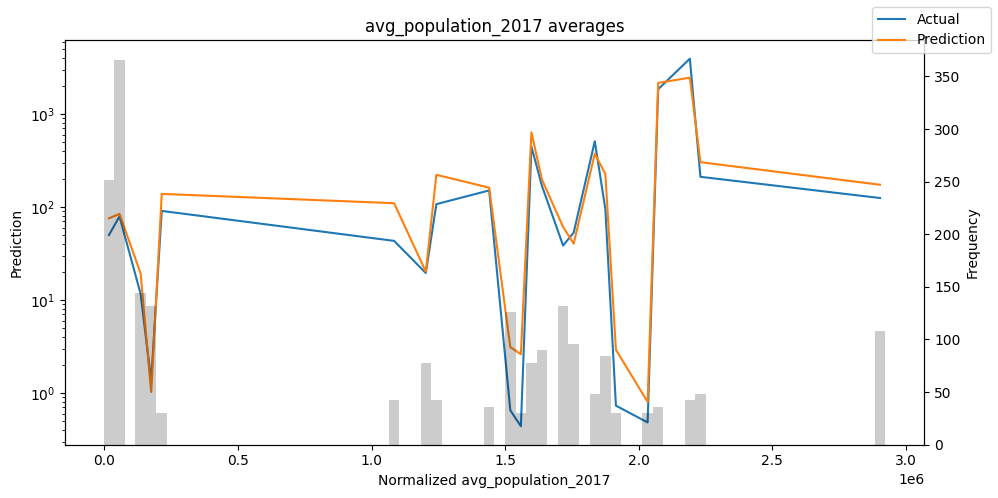

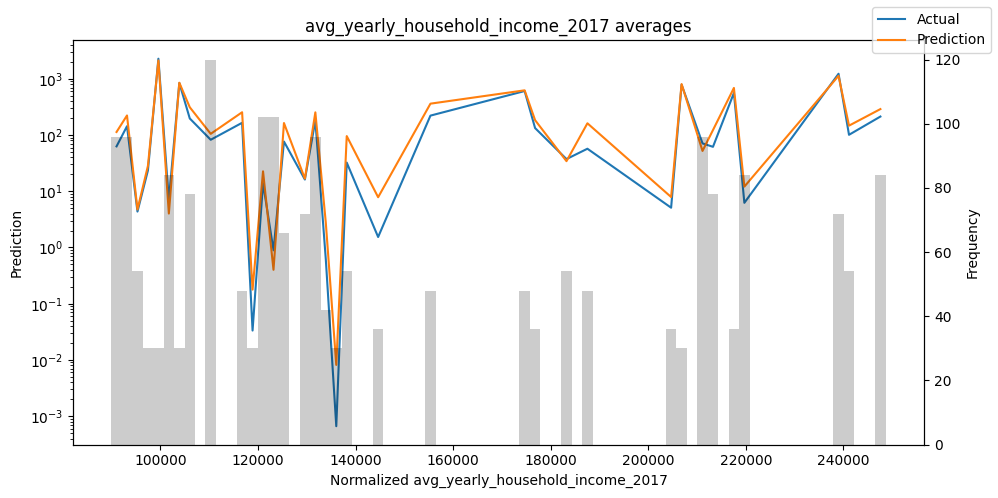

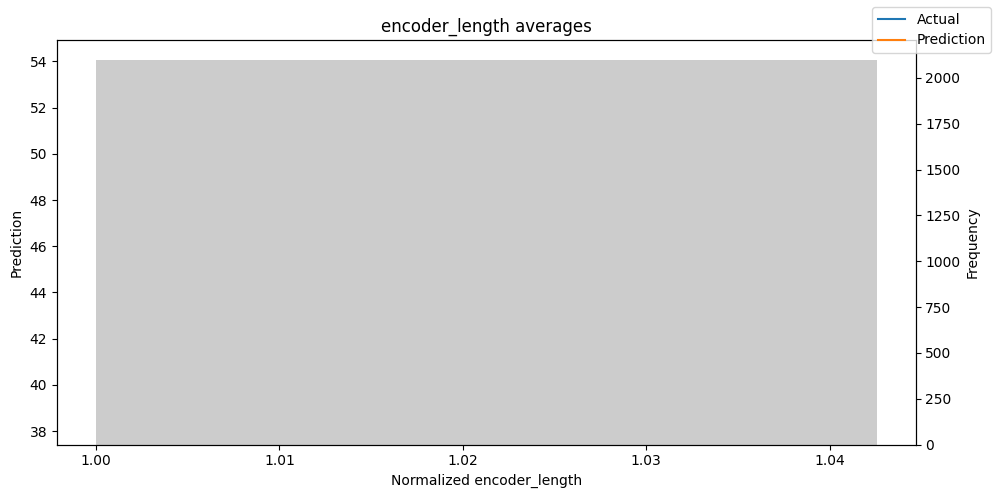

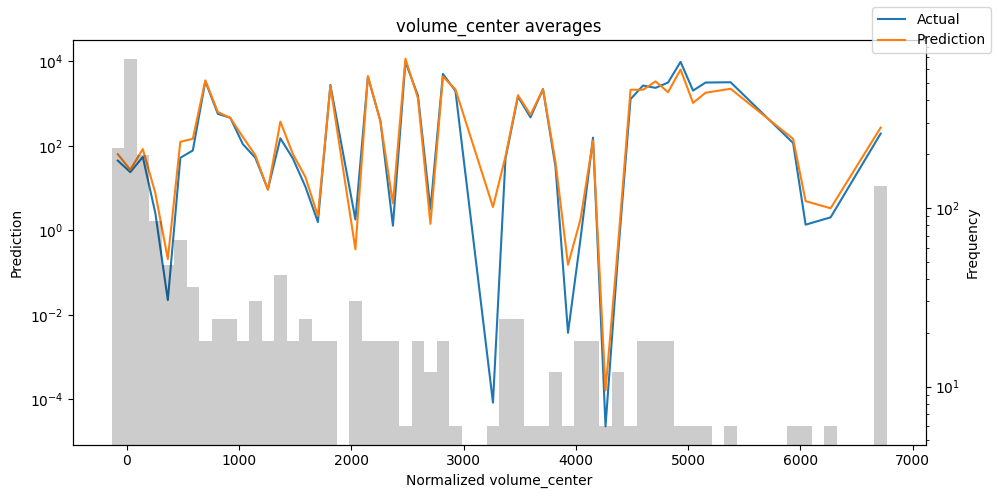

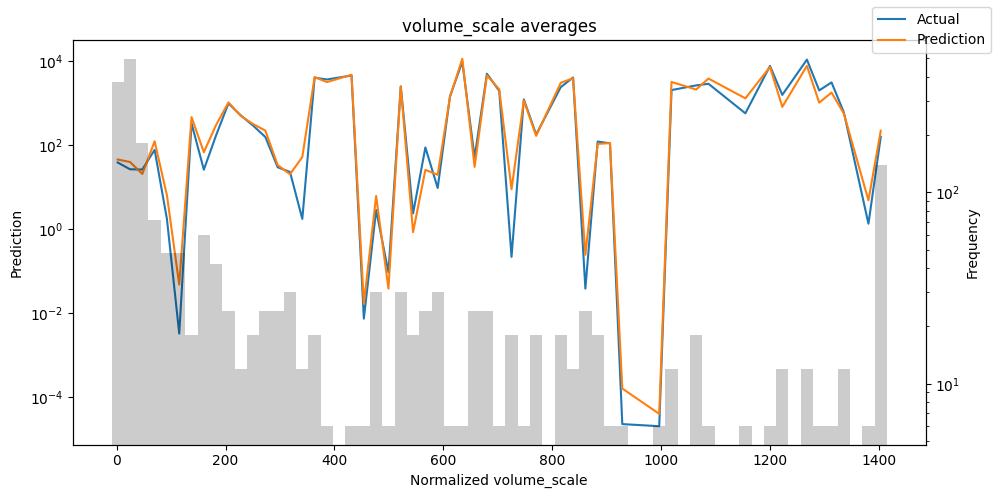

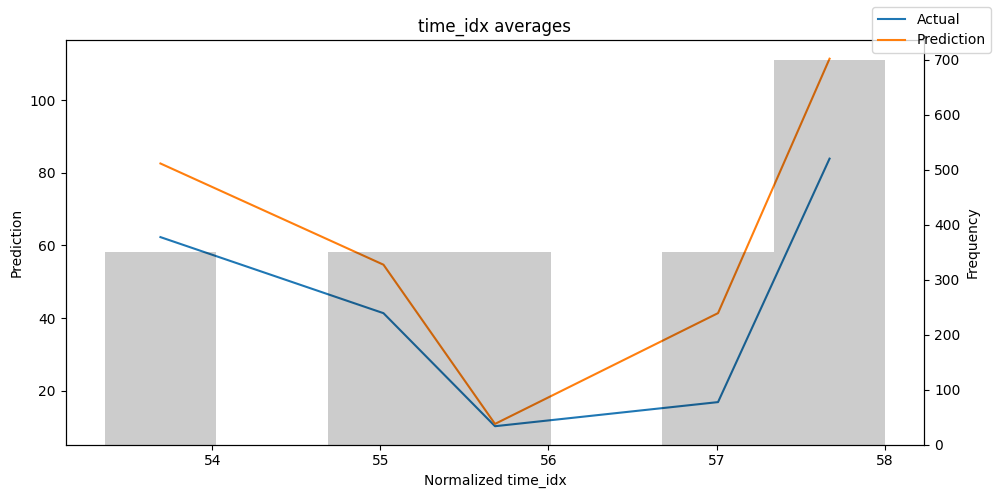

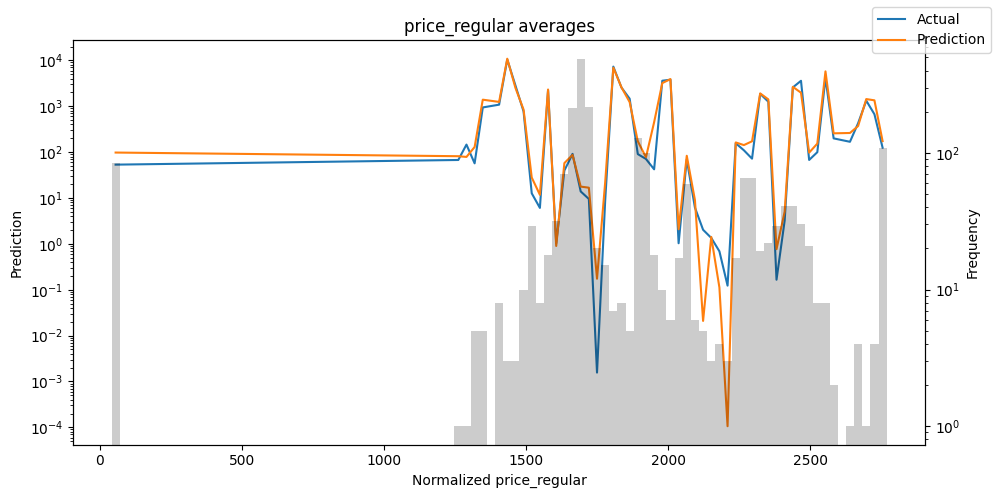

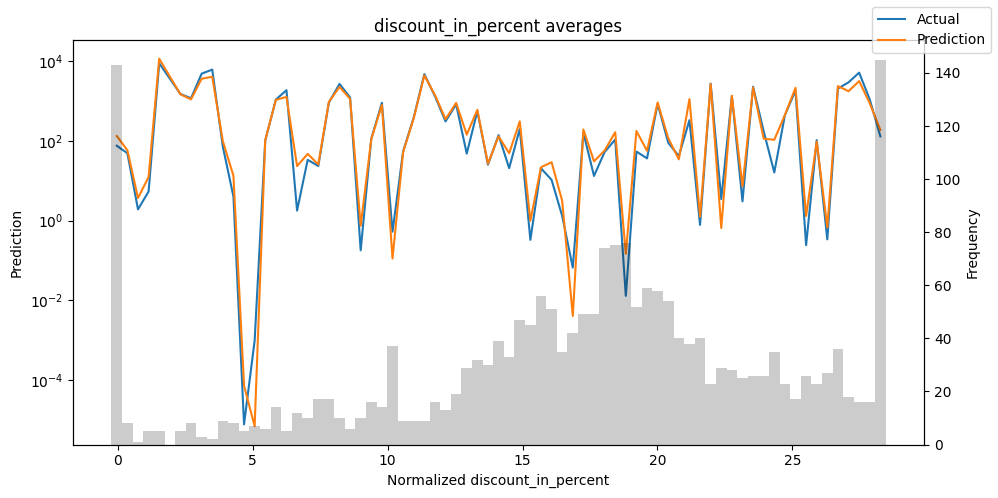

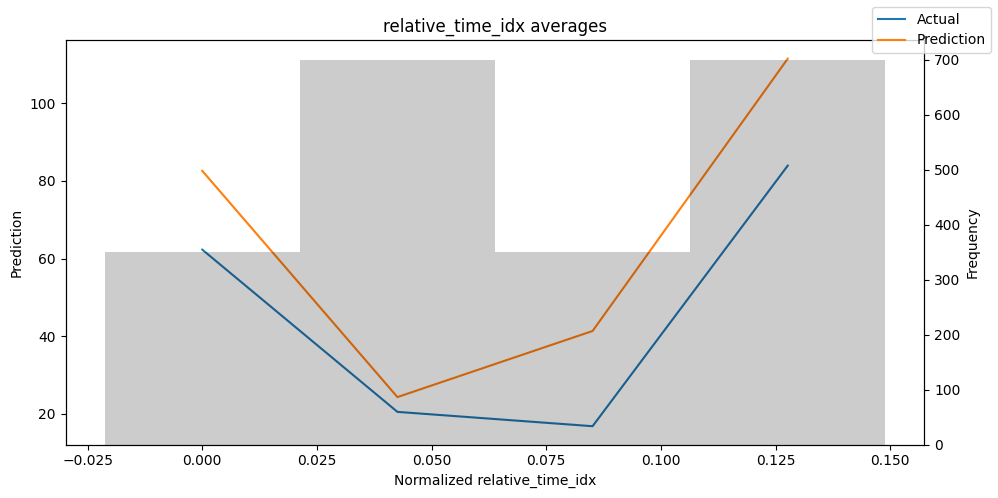

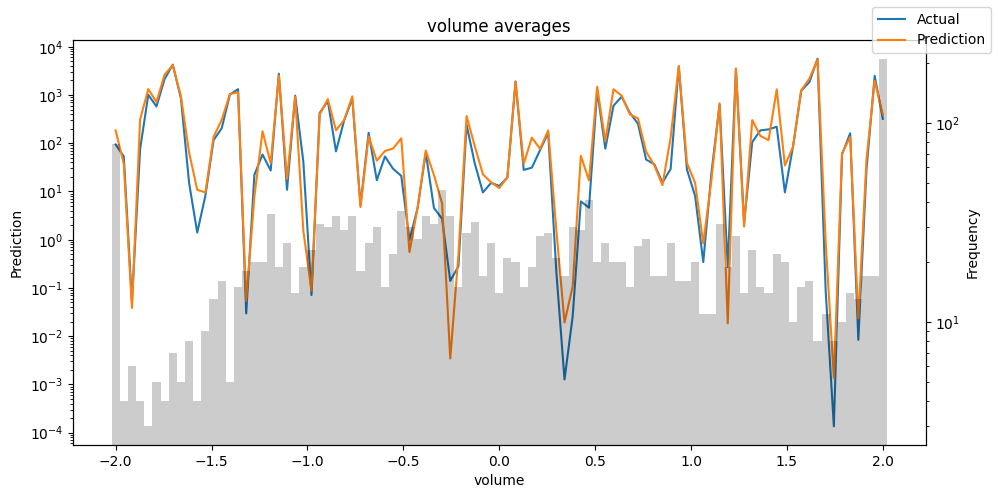

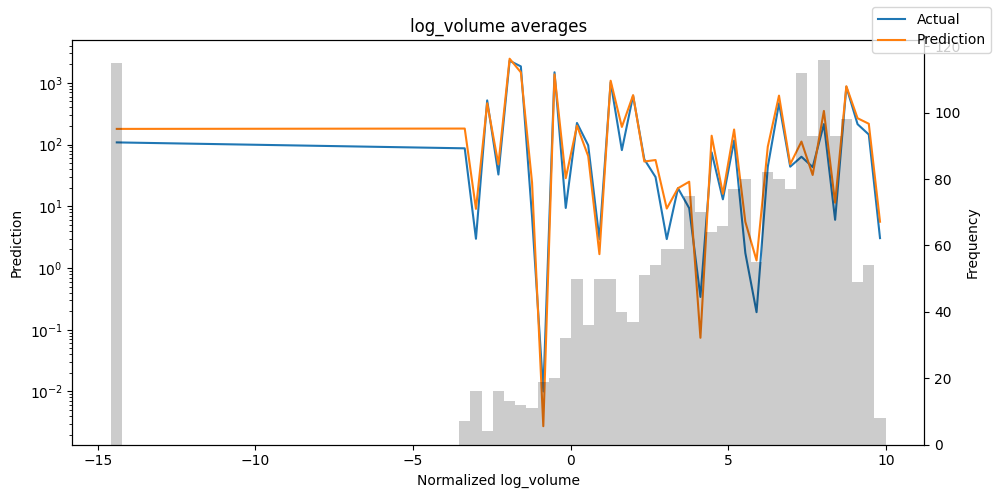

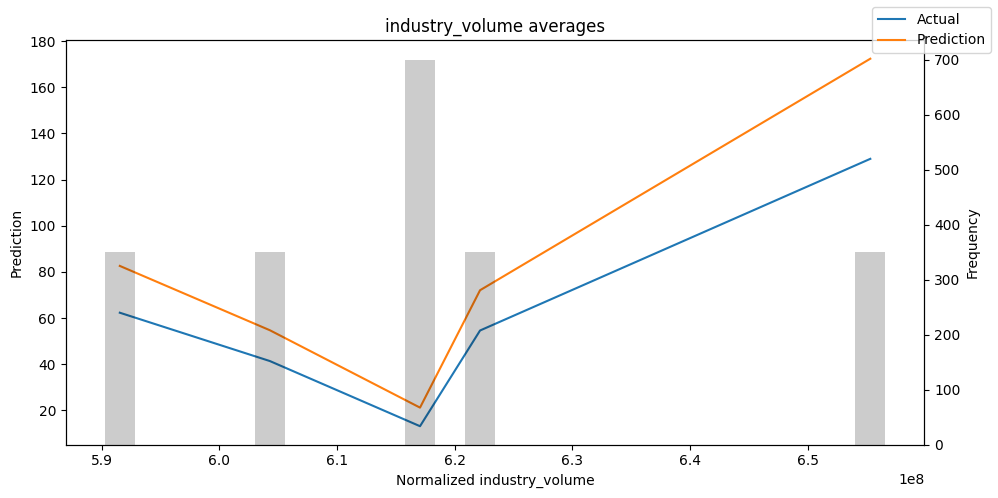

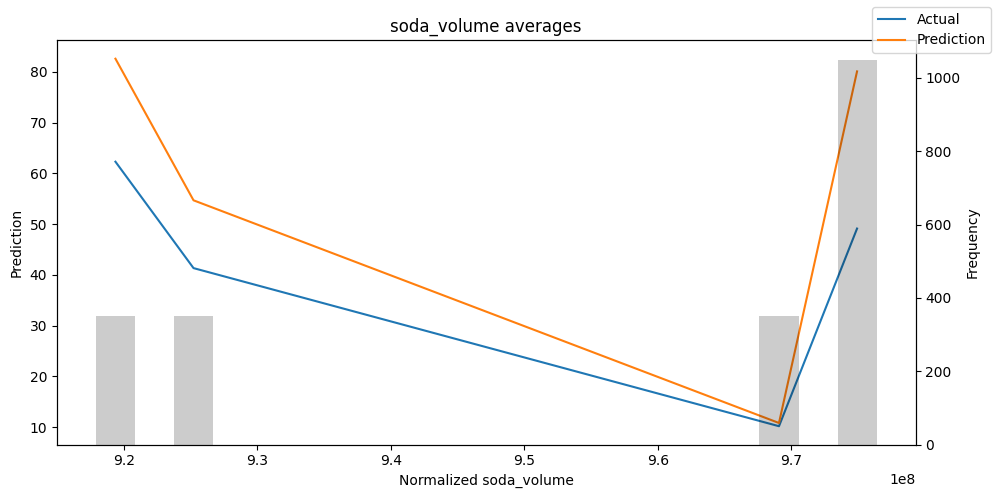

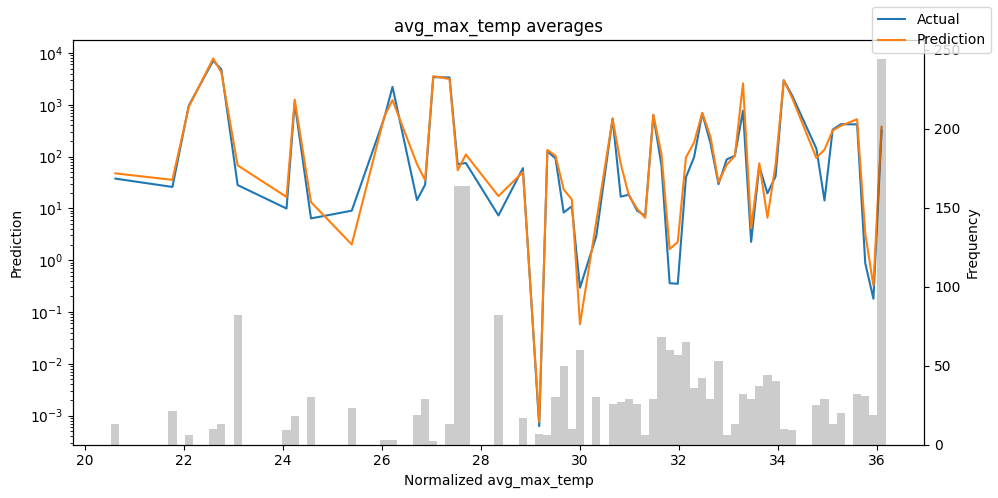

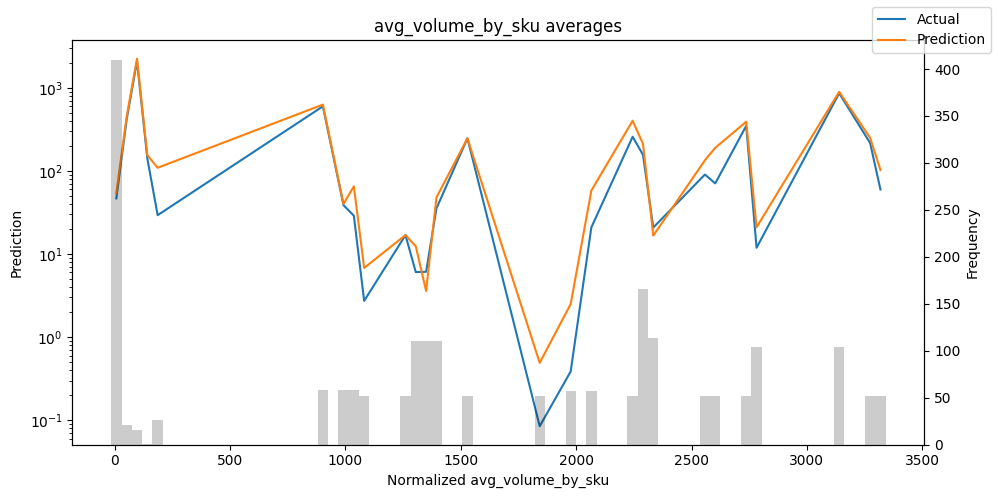

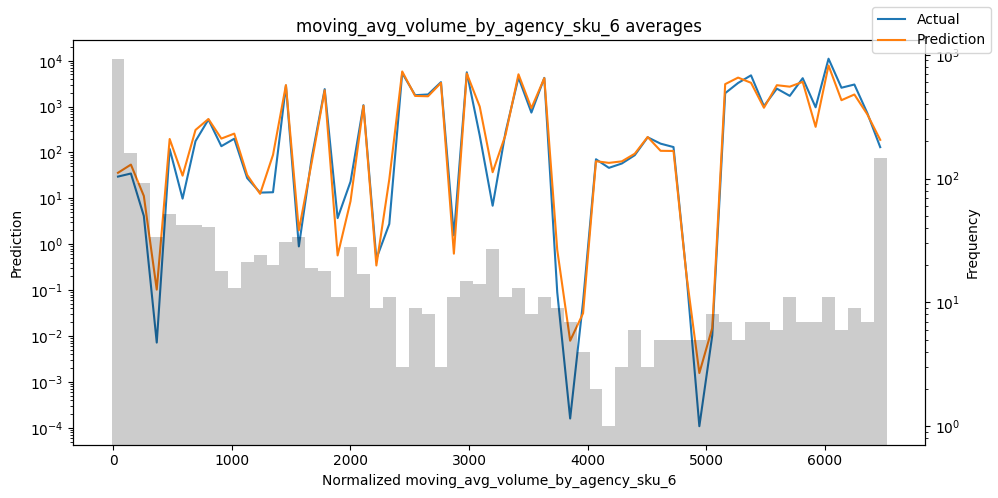

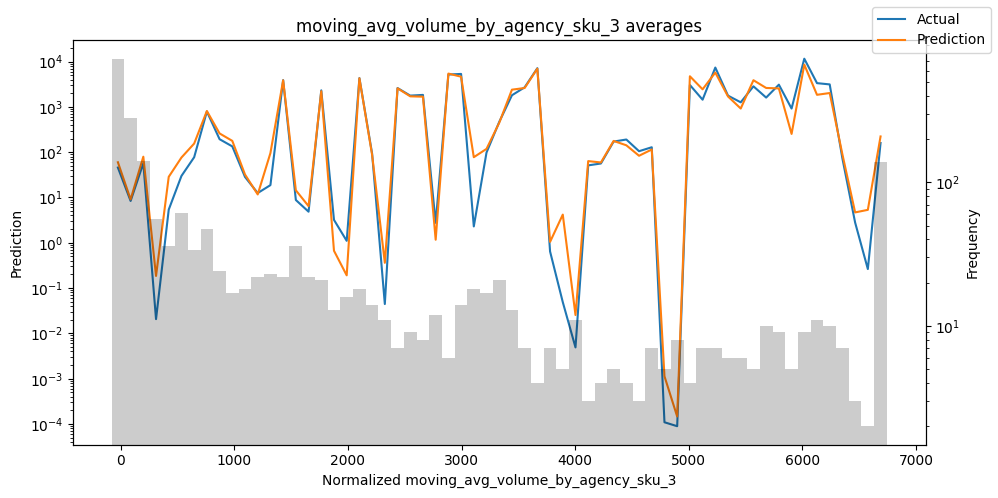

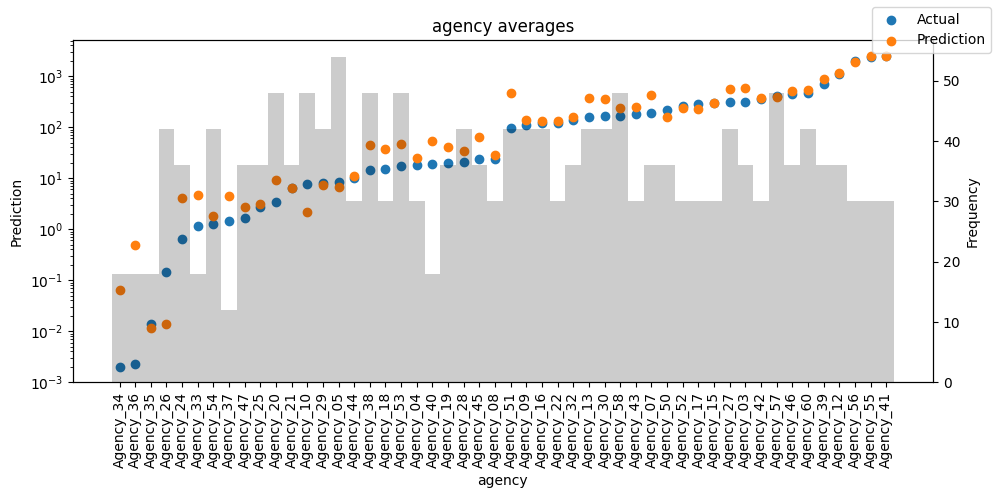

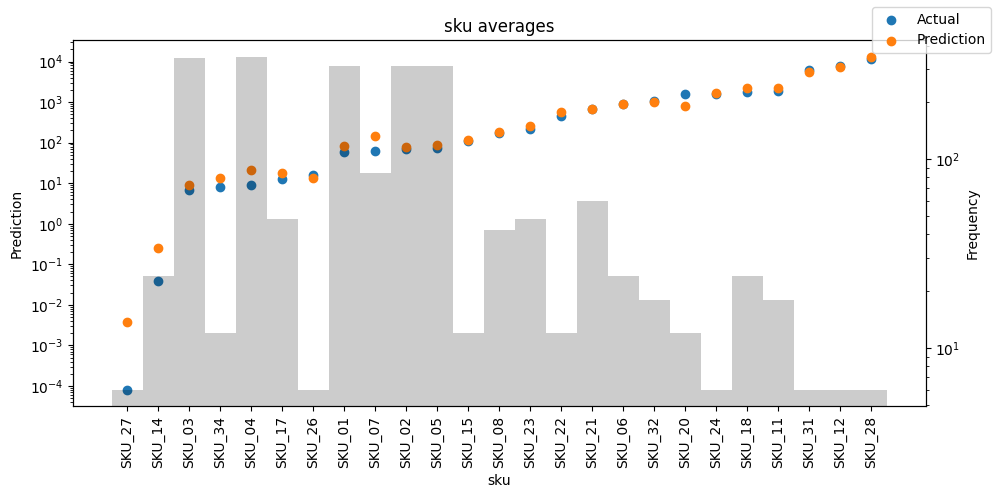

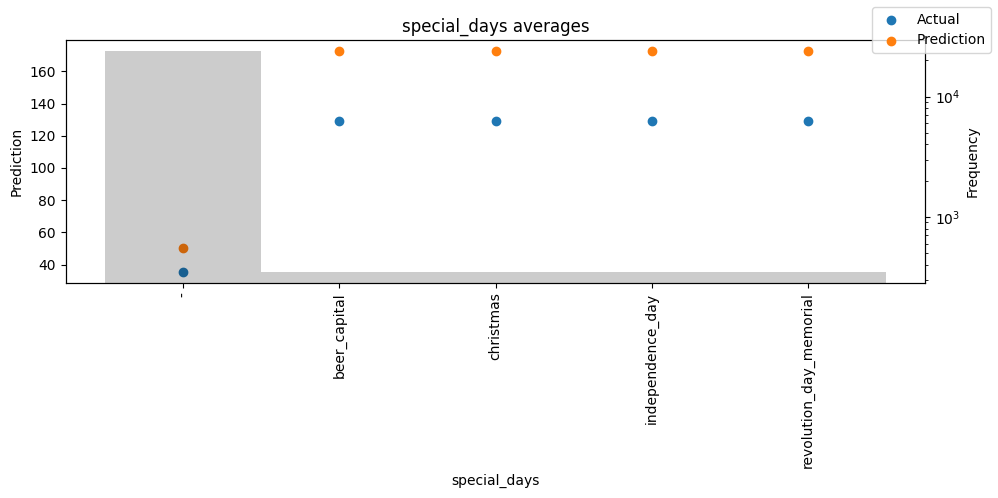

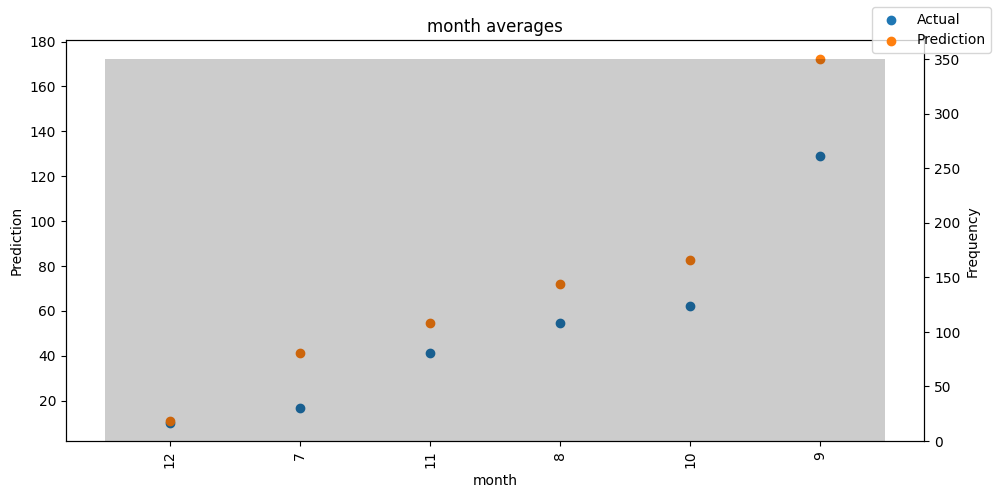

In [15]:
predictions = best_tft.predict(
    val_dataloader, return_x=True, trainer_kwargs=dict(accelerator="gpu")
)
predictions_vs_actuals = best_tft.calculate_prediction_actual_by_variable(
    predictions.x, predictions.output
)
best_tft.plot_prediction_actual_by_variable(predictions_vs_actuals)

#### Predict on new data


In [16]:
# Because we have covariates in the dataset, predicting on new data requires us to define the known covariates upfront.
# select last 24 months from data (max_encoder_length is 24)
max_encoder_length = 24
encoder_data = data[data["time_idx"] > (data["time_idx"].max() - max_encoder_length)]

# select last known data point and create decoder data from it by repeating it and incrementing the month
# in a real world dataset, we should not just forward fill the covariates but specify them to account
# for changes in special days and prices (which you absolutely should do but we are too lazy here)
last_data = data[lambda x: x.time_idx == x.time_idx.max()]
decoder_data = pd.concat(
    [
        last_data.assign(date=lambda x: x.date + pd.offsets.MonthBegin(i))
        for i in range(1, max_prediction_length + 1)
    ],
    ignore_index=True,
)

# add time index consistent with "data"
decoder_data["time_idx"] = (
    decoder_data["date"].dt.year * 12 + decoder_data["date"].dt.month
)
decoder_data["time_idx"] += (
    encoder_data["time_idx"].max() + 1 - decoder_data["time_idx"].min()
)

# adjust additional time feature(s)
decoder_data["month"] = decoder_data.date.dt.month.astype(str).astype(
    "category"
)  # categories have be strings

# combine encoder and decoder data
new_prediction_data = pd.concat([encoder_data, decoder_data], ignore_index=True)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


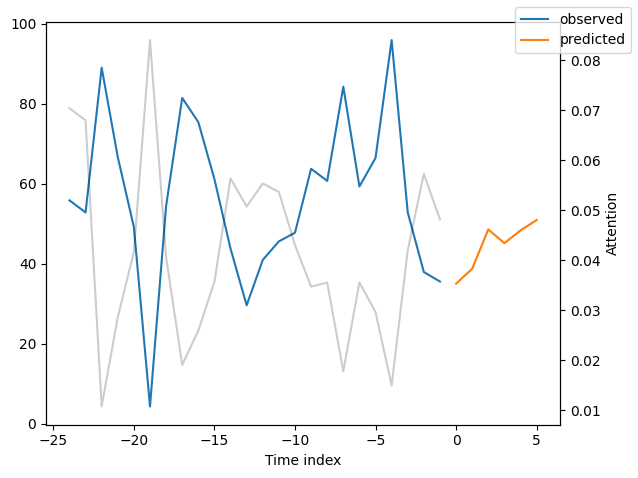

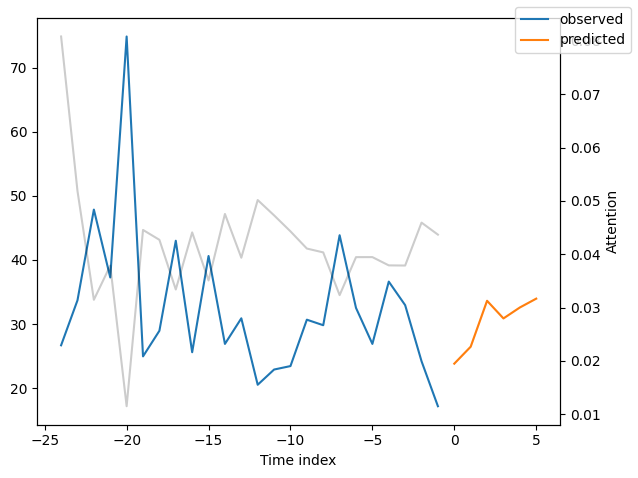

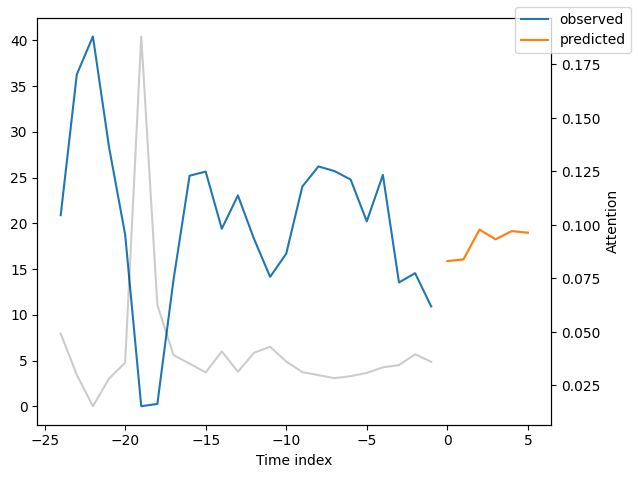

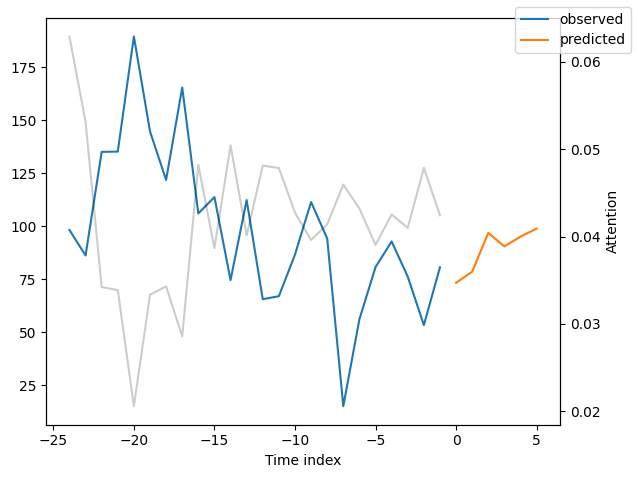

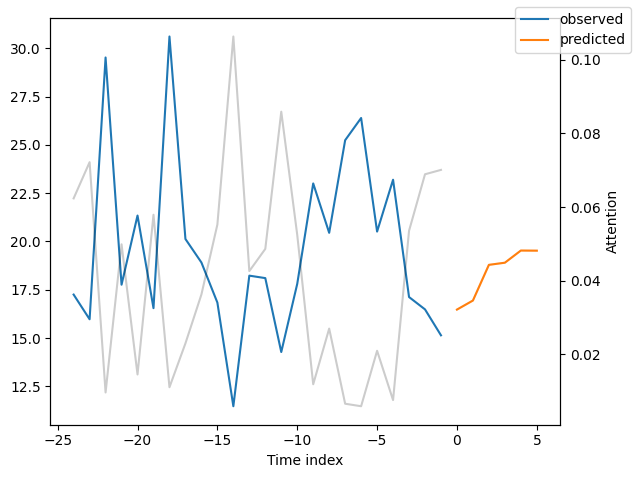

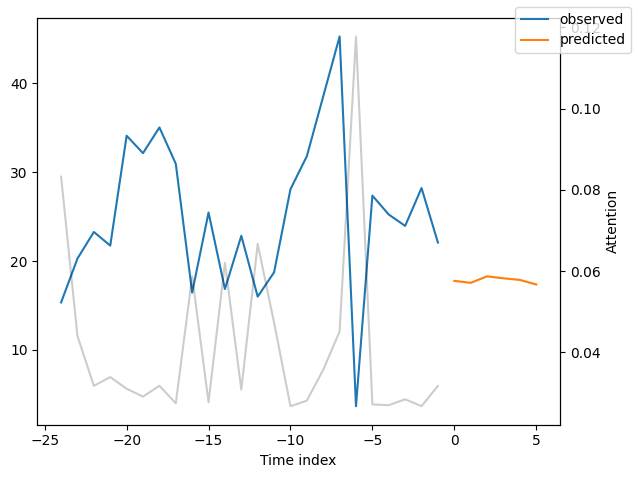

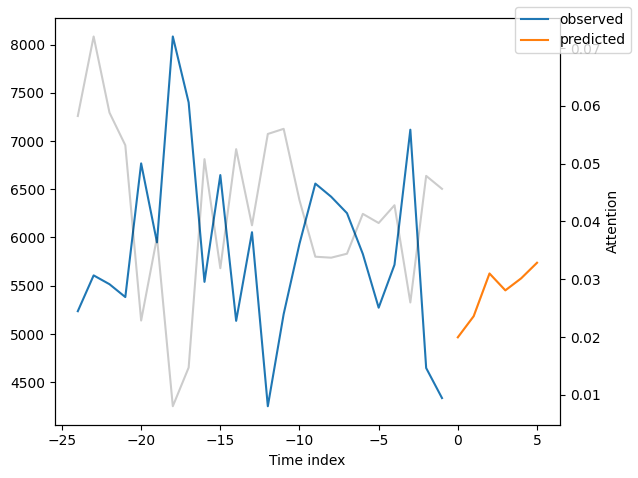

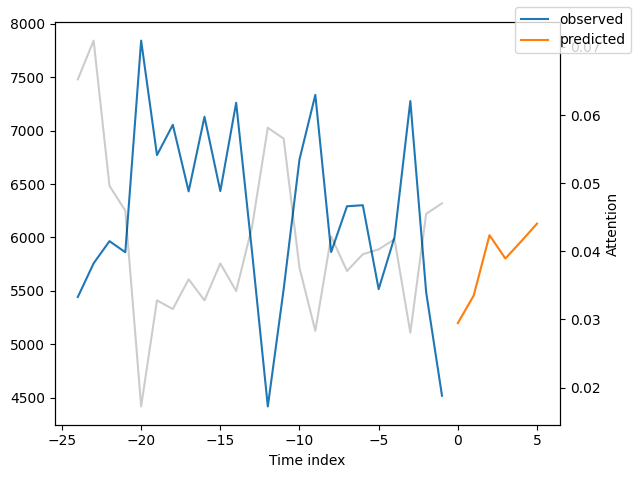

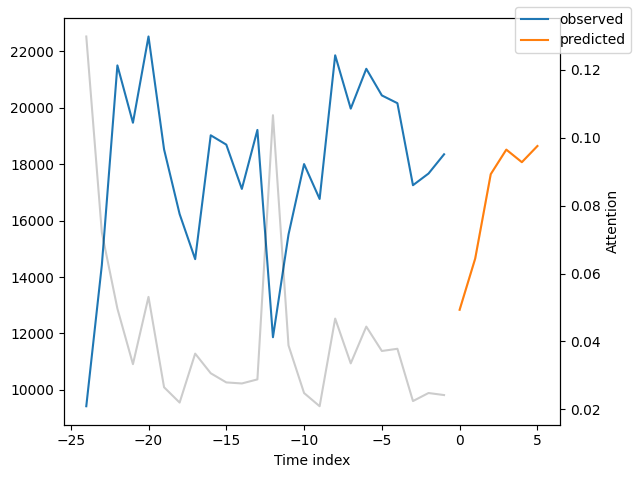

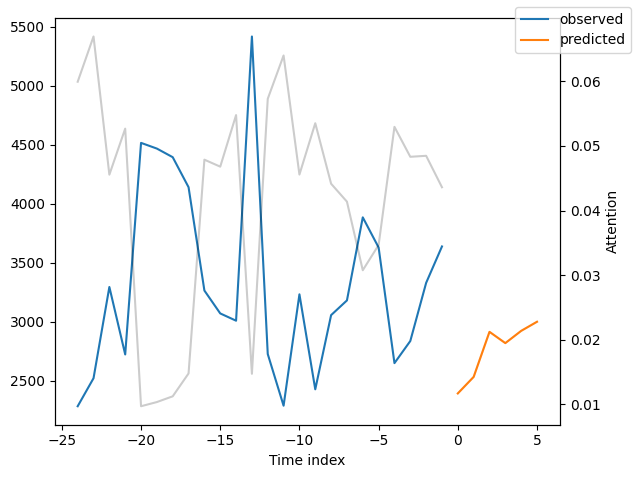

In [17]:
new_raw_predictions = best_tft.predict(
    new_prediction_data,
    mode="raw",
    return_x=True,
    trainer_kwargs=dict(accelerator="gpu"),
)

for idx in range(10):  # plot 10 examples
    best_tft.plot_prediction(
        new_raw_predictions.x,
        new_raw_predictions.output,
        idx=idx,
        show_future_observed=False,
    )

#### Interpret the TFT model


{'attention': <Figure size 640x480 with 1 Axes>,
 'static_variables': <Figure size 700x375 with 1 Axes>,
 'encoder_variables': <Figure size 700x550 with 1 Axes>,
 'decoder_variables': <Figure size 700x350 with 1 Axes>}

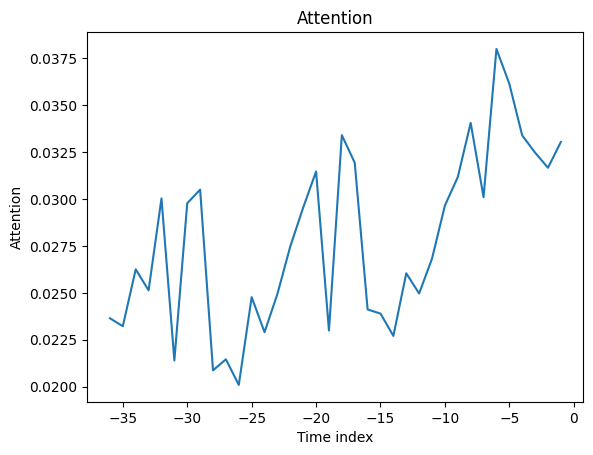

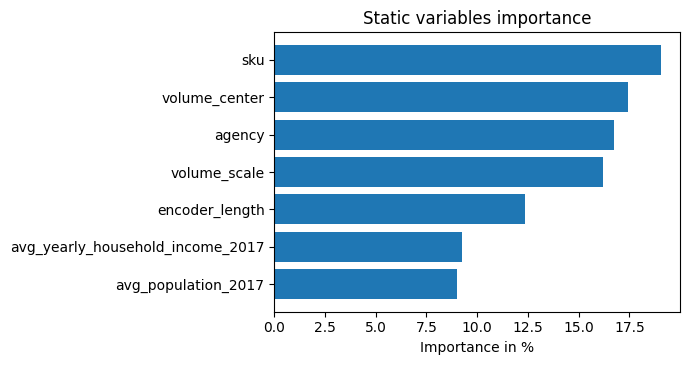

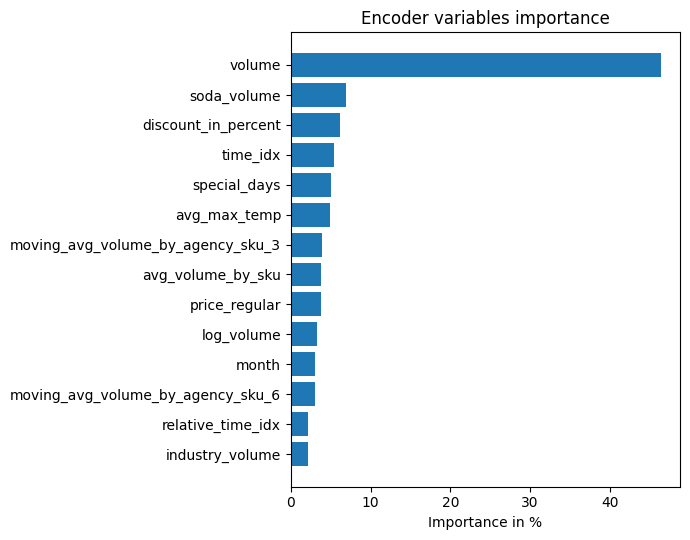

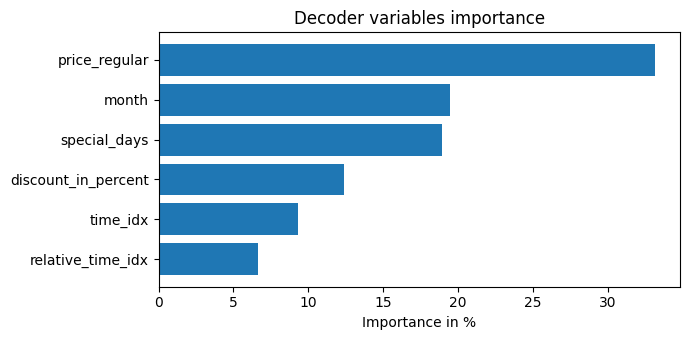

In [18]:
interpretation = best_tft.interpret_output(raw_predictions.output, reduction="sum")
best_tft.plot_interpretation(interpretation)